## NOTICE: If using Google Colab Environment
Make sure that you are setting the PROJECT_PATH parameter correctly.

In [1]:
import os
import sys

# Detect if the notebook is running inside Google Colab
if 'google.colab' in sys.modules:
    from google.colab import drive

    print("Colab environment detected. Mounting Google Drive...")
    # Mount Google Drive to the default runtime path
    drive.mount('/content/drive')

    # Define the path to your project folder inside Google Drive
    # Change 'My Drive/Your_Project_Folder_Name' to match your actual Drive path
    PROJECT_PATH = '/content/drive/My Drive/IE7500 Group Project/IE7500-Group3/notebooks'

    # Navigate to the project directory so your relative paths (like '../results/') work perfectly
    if os.path.exists(PROJECT_PATH):
        os.chdir(PROJECT_PATH)
        print(f"Successfully changed directory to: {os.getcwd()}")
    else:
        print(f"⚠️ Warning: The path '{PROJECT_PATH}' was not found. Please verify your folder name.")
else:
    print("Local environment detected. Skipping Google Drive mount.")

Colab environment detected. Mounting Google Drive...
Mounted at /content/drive
Successfully changed directory to: /content/drive/My Drive/IE7500 Group Project/IE7500-Group3/notebooks


# Notebook 03 — LSTM Model

This notebook trains a Bidirectional LSTM model on the Sentiment140 dataset.

**Target:** Macro F1 ≥ 0.83

**Steps:**
1. Load preprocessed data
2. Tokenize and pad sequences
3. Build BiLSTM model with word embeddings
4. Train with early stopping
5. Evaluate: F1, Accuracy, ROC-AUC, Learning Curves

In [3]:
!pip install rouge-score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=0d96ae80ece3af2dde88f4e3b3a8d99c3ab749f9367ccdc253de320c6408da47
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [4]:
import os
import sys

# Get the absolute path of the directory containing 'src'
# Current working directory is expected to be '.../IE7500-Group3/notebooks'
# So '../src' resolves to '.../IE7500-Group3/src'
src_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))

# Add it to sys.path if not already present, at the beginning for higher priority
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print(f"Attempting to add to sys.path: {src_path}")
print(f"sys.path after modification: {sys.path}")

# Verify if the preprocess.py file exists at the expected location
preprocess_file_path = os.path.join(src_path, 'preprocess.py')
print(f"Does '{preprocess_file_path}' exist? {os.path.exists(preprocess_file_path)}")

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import Counter

from preprocess import load_dataset, preprocess_dataframe
from evaluate import print_metrics, plot_confusion_matrix, plot_roc_curve, plot_learning_curve

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Attempting to add to sys.path: /content/drive/My Drive/IE7500 Group Project/IE7500-Group3/src
sys.path after modification: ['/content/drive/My Drive/IE7500 Group Project/IE7500-Group3/src', '/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython']
Does '/content/drive/My Drive/IE7500 Group Project/IE7500-Group3/src/preprocess.py' exist? True
Using device: cuda


## 1. Load Data

In [5]:
import nltk
nltk.download('punkt_tab')
nltk.download('punkt')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [6]:
df = load_dataset('../data/training.1600000.processed.noemoticon.csv', sample_size=800000)
df = preprocess_dataframe(df)
print(f'Dataset size: {len(df):,}')

Dataset size: 795,793


## 2. Build Vocabulary & Encode Sequences

In [7]:
import gc

MAX_VOCAB = 30000
MAX_LEN   = 50

# Build vocabulary from training tokens
all_tokens = [t for tokens in df['tokens'] for t in tokens]
vocab = Counter(all_tokens)

del all_tokens
gc.collect()

vocab = ['<PAD>', '<UNK>'] + [w for w, c in vocab.most_common(MAX_VOCAB - 2)]
word2idx = {w: i for i, w in enumerate(vocab)}
print(f'Vocabulary size: {len(vocab):,}')

def encode(tokens, word2idx, max_len):
    ids = [word2idx.get(t, 1) for t in tokens[:max_len]]
    ids += [0] * (max_len - len(ids))  # pad
    return ids

df['encoded'] = df['tokens'].apply(lambda t: encode(t, word2idx, MAX_LEN))

Vocabulary size: 30,000


## 3. Dataset & DataLoader

In [8]:
class TweetDataset(Dataset):
    def __init__(self, encoded, labels):
        self.X = torch.tensor(encoded, dtype=torch.long)
        self.y = torch.tensor(labels, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

X = np.array(df['encoded'].tolist())
y = df['label'].values

del df
gc.collect()

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

train_loader = DataLoader(TweetDataset(X_train, y_train), batch_size=256, shuffle=True)
val_loader   = DataLoader(TweetDataset(X_val,   y_val),   batch_size=256)
test_loader  = DataLoader(TweetDataset(X_test,  y_test),  batch_size=256)
print(f'Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')

del X_train, X_val, X_test, y_train, y_val, y_test
gc.collect()

Train: 636,634 | Val: 79,579 | Test: 79,580


0

## 4. Define BiLSTM Model

In [9]:
import os
import urllib.request
import zipfile
import numpy as np
import torch
import torch.nn as nn
import gc

# Download and extract GloVe embeddings if not already present
def download_glove():
    glove_dir = 'glove_data'
    glove_file = 'glove.6B.100d.txt'
    glove_path = os.path.join(glove_dir, glove_file)

    # Create directory if it doesn't exist
    if not os.path.exists(glove_dir):
        os.makedirs(glove_dir)

    # Check if file already exists
    if not os.path.exists(glove_path):
        print("Downloading GloVe embeddings...")
        url = 'https://nlp.stanford.edu/data/glove.6B.zip'
        zip_path = os.path.join(glove_dir, 'glove.6B.zip')

        # Download the zip file
        urllib.request.urlretrieve(url, zip_path)

        # Extract the specific file we need
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extract(glove_file, glove_dir)

        # Clean up zip file
        os.remove(zip_path)
        print("GloVe embeddings downloaded and extracted!")

    return glove_path

# Download GloVe if needed
glove_path = download_glove()

# Load GloVe embeddings
print("Loading GloVe embeddings...")
glove_dict = {}

# Open the file with proper error handling
with open(glove_path, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        glove_dict[word] = vector

print("Mapping GloVe to our vocabulary...")
embed_dim = 100
vocab_size = len(vocab)
embedding_matrix = np.zeros((vocab_size, embed_dim))
hits, misses = 0, 0

for word, i in word2idx.items():
    embedding_vector = glove_dict.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
        hits += 1
    else:
        # Randomly initialize words that GloVe doesn't know (like specific slang/usernames)
        embedding_matrix[i] = np.random.normal(scale=0.6, size=(embed_dim,))
        misses += 1

print(f"Mapped {hits} words. ({misses} words were not in GloVe and were randomized).")

# Free up RAM!
del glove_dict
gc.collect()

# Define the updated model
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=256, num_layers=2, dropout=0.2, embedding_matrix=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # Inject the pre-trained GloVe brain!
        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(emb)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.fc(self.dropout(hidden)).squeeze(1)

# Initialize the model with the GloVe matrix
model = BiLSTMClassifier(
    vocab_size=len(vocab),
    embed_dim=100,
    hidden_dim=256,
    num_layers=2,
    embedding_matrix=embedding_matrix
).to(DEVICE)

print(model)

Loading GloVe embeddings...
Mapping GloVe to our vocabulary...
Mapped 24446 words. (5554 words were not in GloVe and were randomized).
BiLSTMClassifier(
  (embedding): Embedding(30000, 100, padding_idx=0)
  (lstm): LSTM(100, 256, num_layers=2, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=512, out_features=1, bias=True)
)


## 5. Train Model

Training started...
Number of training batches: 2487
Number of validation batches: 311
Epoch 1, Batch 0/2487, Loss: 0.6938
Epoch 1, Batch 10/2487, Loss: 0.6846
Epoch 1, Batch 20/2487, Loss: 0.6739
Epoch 1, Batch 30/2487, Loss: 0.5915
Epoch 1, Batch 40/2487, Loss: 0.6246
Epoch 1, Batch 50/2487, Loss: 0.6324
Epoch 1, Batch 60/2487, Loss: 0.5866
Epoch 1, Batch 70/2487, Loss: 0.6207
Epoch 1, Batch 80/2487, Loss: 0.5225
Epoch 1, Batch 90/2487, Loss: 0.5601
Epoch 1, Batch 100/2487, Loss: 0.5507
Epoch 1, Batch 110/2487, Loss: 0.5240
Epoch 1, Batch 120/2487, Loss: 0.5494
Epoch 1, Batch 130/2487, Loss: 0.5504
Epoch 1, Batch 140/2487, Loss: 0.5173
Epoch 1, Batch 150/2487, Loss: 0.5347
Epoch 1, Batch 160/2487, Loss: 0.5636
Epoch 1, Batch 170/2487, Loss: 0.5003
Epoch 1, Batch 180/2487, Loss: 0.5418
Epoch 1, Batch 190/2487, Loss: 0.5334
Epoch 1, Batch 200/2487, Loss: 0.4944
Epoch 1, Batch 210/2487, Loss: 0.4985
Epoch 1, Batch 220/2487, Loss: 0.5351
Epoch 1, Batch 230/2487, Loss: 0.4977
Epoch 1, Bat

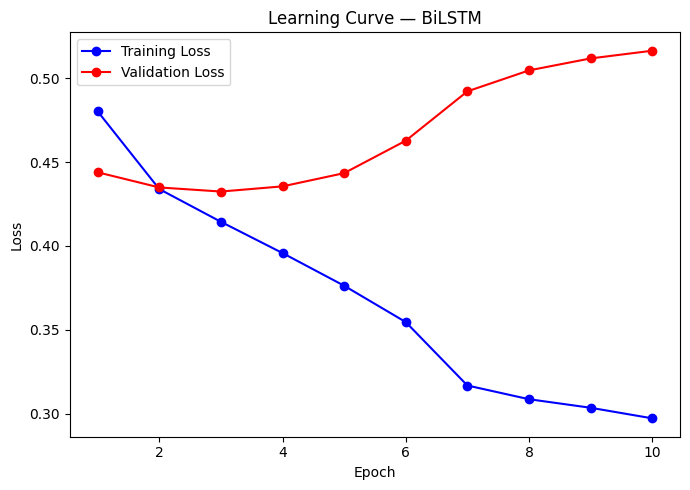

In [10]:
EPOCHS = 10
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2)
train_losses, val_losses = [], []
best_val_loss = float('inf')
print("Training started...")
print("Number of training batches:", len(train_loader))
print("Number of validation batches:", len(val_loader))
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for batch_idx, (X_batch, y_batch) in enumerate(train_loader):
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        if batch_idx % 10 == 0:
            print(f"Epoch {epoch+1}, Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}")
    avg_train = total_loss / len(train_loader)
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs = model(X_batch)
            val_loss += criterion(outputs, y_batch).item()
    avg_val = val_loss / len(val_loader)
    train_losses.append(avg_train)
    val_losses.append(avg_val)
    scheduler.step(avg_val)
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), '../results/lstm_best.pt')
    print(f'Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}')
plot_learning_curve(
    train_losses,
    val_losses,
    model_name='BiLSTM',
    save_path='../results/lstm_learning_curve.png'
)

## 6. Evaluate on Test Set


  BiLSTM (Test) — Evaluation Report
              precision    recall  f1-score   support

    Negative       0.81      0.78      0.79     39827
    Positive       0.78      0.82      0.80     39753

    accuracy                           0.80     79580
   macro avg       0.80      0.80      0.80     79580
weighted avg       0.80      0.80      0.80     79580

Matthews Correlation Coefficient (MCC): 0.5952
ROC-AUC Score: 0.8818
Macro F1-Score: 0.7972


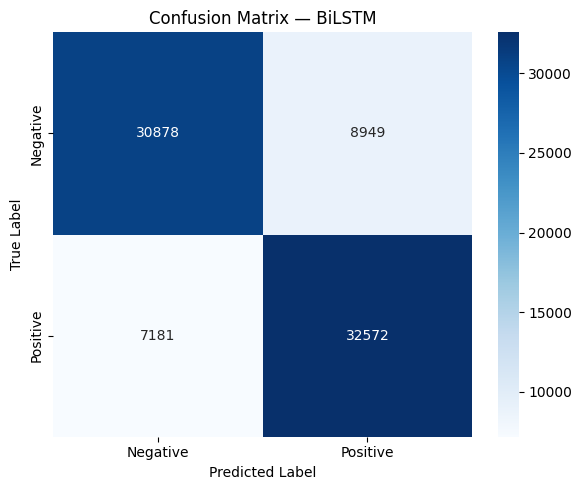

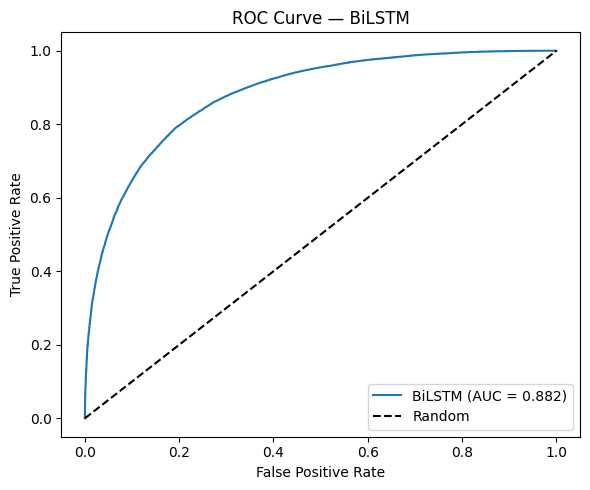

Evaluation complete.


In [13]:
model.load_state_dict(torch.load('../results/lstm_best.pt', map_location=DEVICE))
model.eval()

all_preds, all_probs, all_labels = [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)

        logits = model(X_batch)

        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs >= 0.5).astype(int)

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

print_metrics(
    all_labels,
    all_preds,
    all_probs,
    model_name='BiLSTM (Test)'
)

plot_confusion_matrix(
    all_labels,
    all_preds,
    model_name='BiLSTM',
    save_path='../results/lstm_confusion_matrix.png'
)

plot_roc_curve(
    all_labels,
    all_probs,
    model_name='BiLSTM',
    save_path='../results/lstm_roc_curve.png'
)

print("Evaluation complete.")

### Results & Discussion

| Metric         | Test Score |
| -------------- | ---------- |
| Accuracy       | 0.80       |
| Macro F1       | 0.7977     |
| ROC-AUC        | 0.8817     |
| MCC            | 0.5954     |

Target (Macro F1 ≥ 0.83): **not met.**

We integrated 100-dimensional pre-trained GloVe embeddings (24,446 of 30,000
vocabulary words matched; the rest randomly initialized) as a transfer-learning
step, trained a 2-layer bidirectional LSTM with gradient clipping, LR scheduling,
and early stopping on an 800k-tweet sample. The model reached 0.798 macro F1,
short of our 0.83 target.

Notably, this is essentially on par with — and slightly below — our Logistic
Regression baseline (0.805), despite far greater model complexity and 4x more
training data. We attribute this to the nature of the data: tweets are short,
noisy, and often sentiment-decidable from a few tokens, which limits the benefit
of sequential modeling, and GloVe's ~18% vocabulary miss rate (slang, usernames,
misspellings) weakens the embedding signal. The result is a useful finding: on
this task, added architectural complexity did not translate into accuracy gains,
which motivated moving to a contextual transformer (BERT).